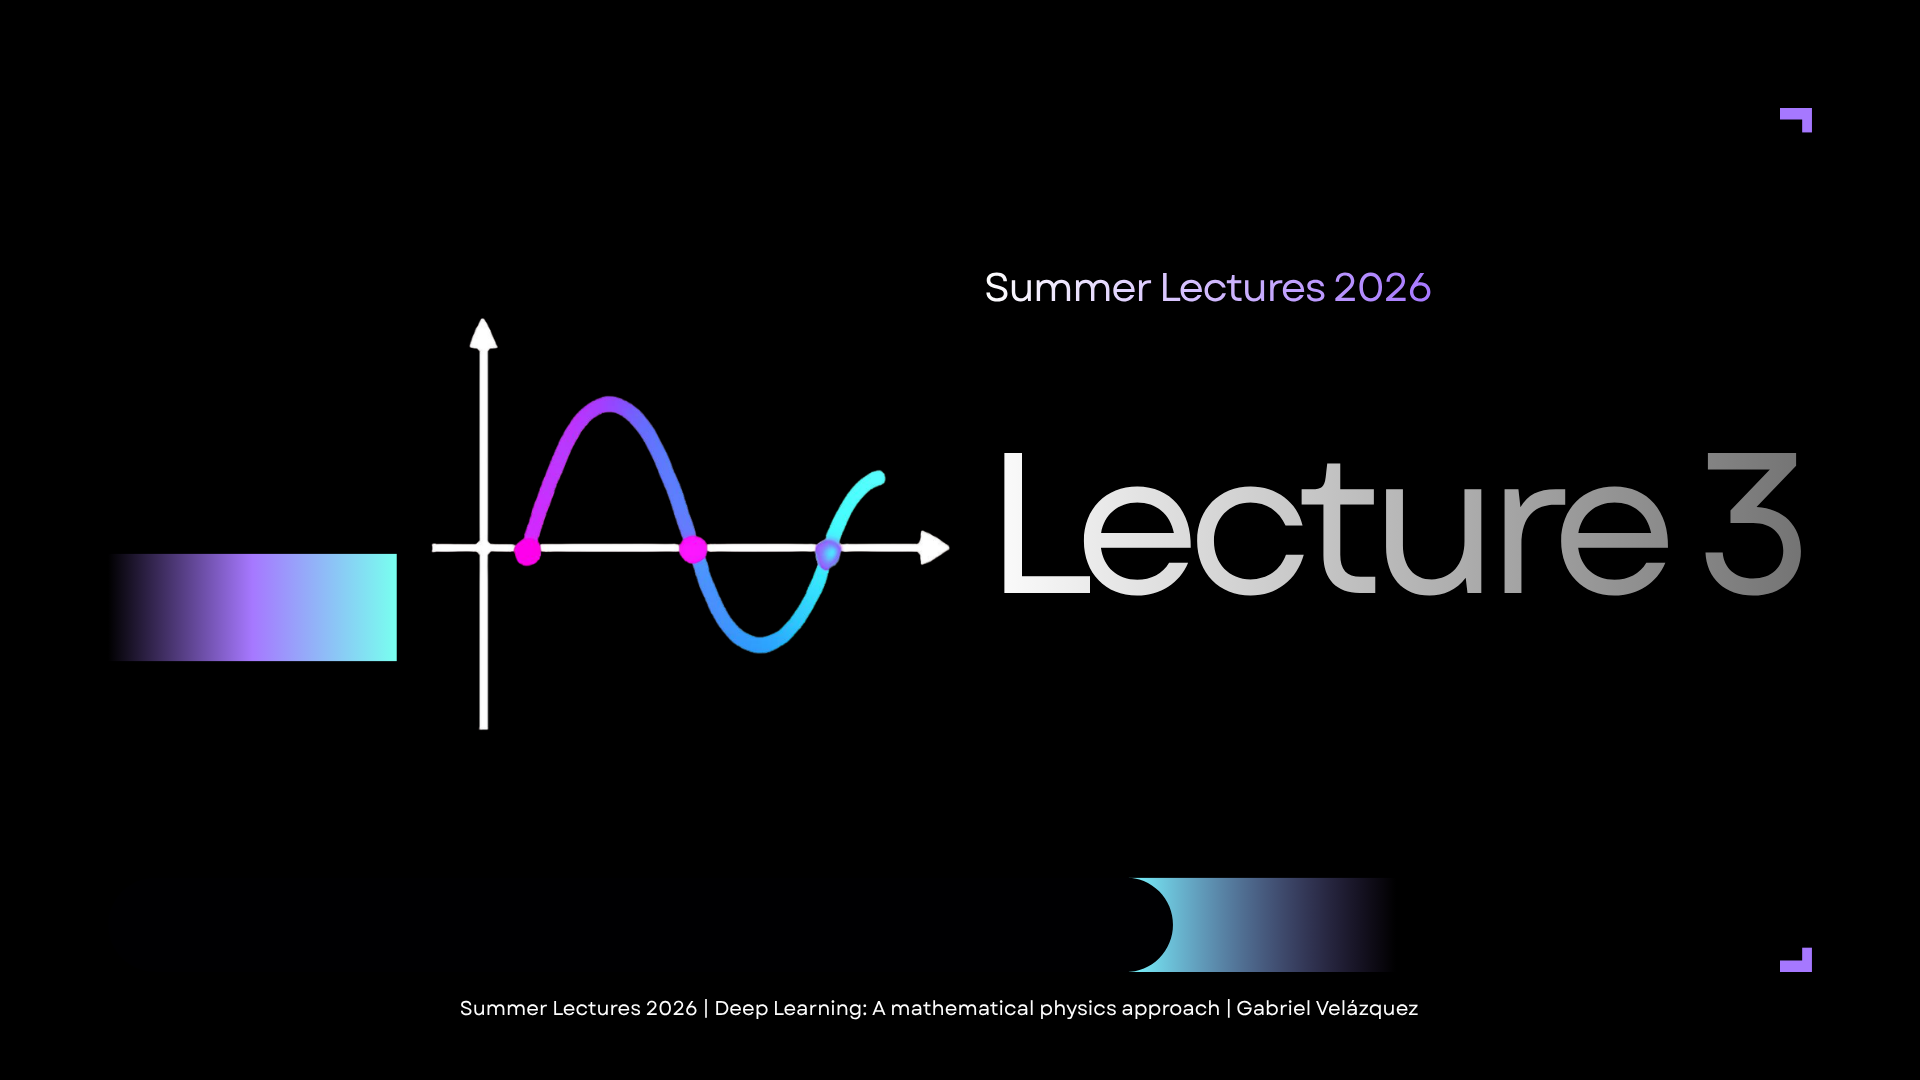

# Linear Algebra

How can a computer solve equations reliably, and how can we tell whether the result is useful?
We build the main algorithms with **NumPy**, inspect what they do, and explore the sensitivity of linear systems. Matplotlib makes the geometry of systems and determinants visible.

**Learning goals.** By the end, you should be able to:

- Interpret $A\mathbf{x}=\mathbf{b}$ and distinguish matrix products from elementwise operations.
- Explain elimination, pivot selection, and the factorization $PA=LU$.
- Solve several systems using one factorization and compute a determinant from its pivots.
- Distinguish **conditioning**, **algorithmic stability**, **residuals**, and **forward error**.
- Check solutions and explain why a small residual may coexist with a large forward error.

The implementations favor readability for small, dense, real-valued systems. Production computations should use established numerical solvers; the purpose here is to understand the machinery.


## 1. Preparation and the meaning of a linear system

Each **row** of $A$ is one equation; each **column** contains the coefficients of one unknown. We store a vector as a one-dimensional NumPy array with shape `(n,)`. Its transpose still has shape `(n,)`; use `x[:, None]` when you need an explicit column.

In NumPy, `A @ x` means a matrix–vector product. `A * x` multiplies entries using broadcasting and does **not** solve or evaluate the same operation.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

BG="#000000"; INK="#F0F2F5"; MUTED="#9AA3AD"; GRID="#263039"
CYAN="#3DD6C4"; GOLD="#F4C95D"; VIOLET="#A78BFA"; ORANGE="#E8956B"
BLUE="#5BC8F5"; GREEN="#7BE08A"; RED="#FF6F61"

plt.rcParams.update({
    "figure.facecolor":BG,"axes.facecolor":BG,"savefig.facecolor":BG,"savefig.bbox":"tight",
    "axes.edgecolor":MUTED,"axes.labelcolor":MUTED,"text.color":INK,"xtick.color":MUTED,
    "ytick.color":MUTED,"axes.titlecolor":INK,"axes.grid":True,"grid.color":GRID,
    "grid.linewidth":0.8,"axes.spines.top":False,"axes.spines.right":False,"font.size":11,
    "axes.titleweight":"bold","figure.figsize":(8,4.6),
    "legend.facecolor":BG,"legend.edgecolor":MUTED,"legend.labelcolor":INK,
})

def show_aug(M, v, caption=""):
    """Print an augmented matrix [A | b] with aligned columns."""
    if caption: print("  ·", caption)
    for i in range(len(v)):
        row=" ".join(f"{M[i,j]:7.3g}" for j in range(M.shape[1]))
        print(f"     [ {row}  | {v[i]:7.3g} ]")
    print()
np.set_printoptions(precision=5, suppress=True)
print("Ready. NumPy", np.__version__)


Ready. NumPy 2.3.5


A shape: (2, 2) | b shape: (2,)
Solution: [1. 2.] | A @ x: [3. 0.]


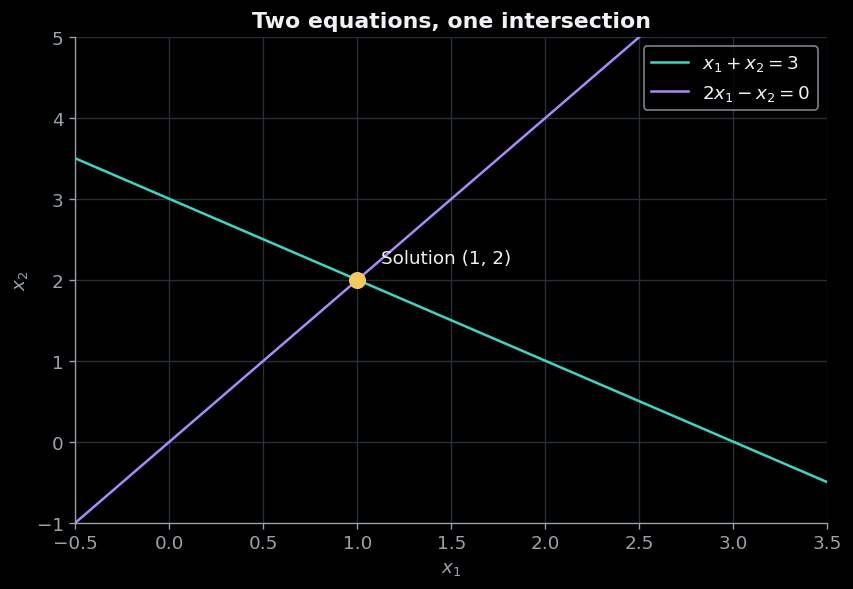

In [ ]:
A_geometry = np.array([[1., 1.], [2., -1.]])
b_geometry = np.array([3., 0.])
x_geometry = np.linalg.solve(A_geometry, b_geometry)
print("A shape:", A_geometry.shape, "| b shape:", b_geometry.shape)
print("Solution:", x_geometry, "| A @ x:", A_geometry @ x_geometry)

xx = np.linspace(-0.5, 3.5, 200)
fig, ax = plt.subplots(figsize=(7, 4.8), layout="constrained")
ax.plot(xx, 3-xx, color=CYAN, label=r"$x_1+x_2=3$")
ax.plot(xx, 2*xx, color=VIOLET, label=r"$2x_1-x_2=0$")
ax.scatter(*x_geometry, color=GOLD, s=85, zorder=5)
ax.annotate("Solution (1, 2)", x_geometry, xytext=(14, 10), textcoords="offset points")
ax.set(xlabel=r"$x_1$", ylabel=r"$x_2$", title="Two equations, one intersection",
       xlim=(-0.5, 3.5), ylim=(-1, 5))
ax.legend()
plt.show()


**Read the picture.** The intersection satisfies both equations simultaneously. Parallel, distinct lines give no solution; coincident lines give infinitely many. For a square matrix, invertibility guarantees exactly one solution for every right-hand side.

## 2. Gaussian elimination: simplify first, solve second

We transform $A\mathbf{x}=\mathbf{b}$ into an equivalent upper-triangular system $U\mathbf{x}=\widetilde{\mathbf{b}}$. At column $k$, the **pivot** is the diagonal entry used to eliminate entries below it:

$$m_{ik}=\frac{a_{ik}}{a_{kk}},\qquad R_i\leftarrow R_i-m_{ik}R_k.$$

Apply every row operation to **both** $A$ and $\mathbf{b}$. Once the lower triangle is zero, solve from the last equation upward:

$$x_i=\frac{\widetilde b_i-\sum_{j=i+1}^{n-1}u_{ij}x_j}{u_{ii}}.$$

We first deliberately omit pivoting so that its importance will be visible. This version stops on an exactly zero pivot but does not protect against a dangerously small pivot.

**Predict:** verify by hand that $(1,2,3)$ solves the system in the next cell. Then follow each printed augmented matrix.


In [ ]:
def checked_matrix(A):
    """Return a finite, nonempty, square real matrix as a floating-point copy."""
    if np.iscomplexobj(A):
        raise ValueError("This teaching implementation accepts real matrices only.")
    M = np.array(A, dtype=float, copy=True)
    if M.ndim != 2 or M.shape[0] != M.shape[1] or M.shape[0] == 0:
        raise ValueError("A must be a nonempty square matrix.")
    if not np.all(np.isfinite(M)):
        raise ValueError("A must contain finite numbers.")
    return M


def checked_rhs(b, n):
    """Require a one-dimensional right-hand side of length n."""
    if np.iscomplexobj(b):
        raise ValueError("b must be real.")
    v = np.array(b, dtype=float, copy=True)
    if v.shape != (n,) or not np.all(np.isfinite(v)):
        raise ValueError(f"b must be finite and have shape ({n},).")
    return v


def gauss_solve(A, b, verbose=False):
    """Elimination WITHOUT pivoting, for comparison; inputs are not modified."""
    M = checked_matrix(A)
    n = M.shape[0]
    v = checked_rhs(b, n)
    if verbose:
        show_aug(M, v, "initial system [A | b]")
    for k in range(n-1):
        if M[k, k] == 0:
            raise np.linalg.LinAlgError("Zero pivot: row exchanges may be needed.")
        for i in range(k+1, n):
            multiplier = M[i, k] / M[k, k]
            M[i, k:] -= multiplier * M[k, k:]
            M[i, k] = 0.0
            v[i] -= multiplier * v[k]
        if verbose:
            show_aug(M, v, f"eliminate below pivot {k+1}")
    solution = np.zeros(n)
    for i in range(n-1, -1, -1):
        if M[i, i] == 0:
            raise np.linalg.LinAlgError("Zero pivot during back substitution.")
        solution[i] = (v[i] - M[i, i+1:] @ solution[i+1:]) / M[i, i]
    return solution

A_gauss = np.array([[1,1,1], [1,2,3], [1,4,9]], dtype=float)
b_gauss = np.array([6,14,36], dtype=float)
x_gauss = gauss_solve(A_gauss, b_gauss, verbose=True)
print("Solution:", x_gauss)
print("Residual b - A @ x:", b_gauss - A_gauss @ x_gauss)


  · initial system [A | b]
     [       1       1       1  |       6 ]
     [       1       2       3  |      14 ]
     [       1       4       9  |      36 ]

  · eliminate below pivot 1
     [       1       1       1  |       6 ]
     [       0       1       2  |       8 ]
     [       0       3       8  |      30 ]

  · eliminate below pivot 2
     [       1       1       1  |       6 ]
     [       0       1       2  |       8 ]
     [       0       0       2  |       6 ]

Solution: [1. 2. 3.]
Residual b - A @ x: [0. 0. 0.]


## 3. Pivoting: the order of the equations matters numerically

Exact row operations preserve the solution. Floating-point arithmetic also introduces rounding. Dividing by a tiny pivot can create large intermediate values and lose significant information in subtraction.

| Strategy | Choice at step $k$ | Exchanges |
|:--|:--|:--|
| Partial | Largest $|a_{ik}|$ in the active column, $i\geq k$ | Rows |
| Scaled partial | Largest $|a_{ik}|/s_i$, where $s_i=\max_j|a_{ij}|$ is the original row scale | Rows and associated scales |
| Complete | Largest $|a_{ij}|$ in the remaining submatrix | Rows and columns; track unknown order |

A zero row must be handled before dividing by its scale. The next example has no zero rows and compares **only the first pivot choice**, not three full solvers. Partial pivoting is the strategy we implement afterward.


In [ ]:
A = np.array([[2.11, -4.21, 0.921],
              [4.01, 10.2 , -1.12 ],
              [1.09,  0.987, 0.832]])

col0 = np.abs(A[:, 0])
i_partial = int(np.argmax(col0))                       # largest |entry| in column 0
s = np.max(np.abs(A), axis=1)                          # row scales
i_scaled  = int(np.argmax(col0 / s))                   # largest relative to row scale
i_c, j_c  = np.unravel_index(np.argmax(np.abs(A)), A.shape)  # global max

print(f"partial  -> row {i_partial+1}  (|{A[i_partial,0]}|)")
print(f"scaled   -> row {i_scaled+1}  (ratio {col0[i_scaled]/s[i_scaled]:.2f}; row scale s={s[i_scaled]:.3g})")
print(f"complete -> entry ({i_c+1},{j_c+1}) = {A[i_c,j_c]}  (also permutes the unknowns)")
print("\nThe three strategies disagree: partial picks row 2, scaled picks row 3, complete jumps to a22.")


partial  -> row 2  (|4.01|)
scaled   -> row 3  (ratio 1.00; row scale s=1.09)
complete -> entry (2,2) = 10.2  (also permutes the unknowns)

The three strategies disagree: partial picks row 2, scaled picks row 3, complete jumps to a22.


### A tiny pivot can spoil a well-conditioned problem

The next matrix is not close to singular. Its first entry is simply a poor choice of pivot. Swapping the rows avoids dividing by that entry.

**Predict:** will changing the order of the equations change the exact solution? Will it change the computed solution?


In [ ]:
eps = 1e-16
A = [[eps, 1.0],[1.0, 1.0]];  b = [1.0, 2.0]        # true solution ~ (1, 1)
x_naive = gauss_solve(A, b)                          # uses eps as pivot
# partial pivoting = swap the two rows first
x_pivot = gauss_solve([[1.0,1.0],[eps,1.0]], [2.0,1.0])
print(f"no pivoting    -> x = ({x_naive[0]:.3f}, {x_naive[1]:.3f})   (1st component destroyed)")
print(f"partial pivot  -> x = ({x_pivot[0]:.3f}, {x_pivot[1]:.3f})")
print("Condition number (infinity norm):", np.linalg.cond(A, np.inf))
for name, estimate in [("No pivot", x_naive), ("Row exchange", x_pivot)]:
    print(name, "| residual infinity norm:", np.linalg.norm(np.asarray(b)-np.asarray(A)@estimate, np.inf))


no pivoting    -> x = (2.220, 1.000)   (1st component destroyed)
partial pivot  -> x = (1.000, 1.000)
Condition number (infinity norm): 4.0
No pivot | residual infinity norm: 1.220446049250313
Row exchange | residual infinity norm: 0.0


**Interpretation.** The exact solution is $x_1=1/(1-\varepsilon)$, $x_2=(1-2\varepsilon)/(1-\varepsilon)$, approximately $(1,1)$. The inaccurate result without pivoting is an **algorithmic stability** issue, not evidence that this matrix is ill-conditioned. Partial pivoting is effective for many problems but is not a universal guarantee against all rounding-error growth.

## 4. LU factorization: keep the work and reuse it

Elimination produces $U$. Its multipliers form a unit lower-triangular matrix $L$. A permutation matrix $P$ records the row exchanges:

$$PA=LU.$$

To solve $A\mathbf{x}=\mathbf{b}$, use two triangular solves:

$$L\mathbf{y}=P\mathbf{b},\qquad U\mathbf{x}=\mathbf{y}.$$

**Subtle but essential:** when a later row exchange occurs, we must also exchange the previously computed columns of $L$. Swapping only $U$ would break $PA=LU$.

The default pivot tolerance below is $n\epsilon_{\mathrm{mach}}\max_{ij}|a_{ij}|$. It rejects pivots that are too small on this global scale. This is a practical guard for our examples, **not a complete rank or conditioning test**; a badly scaled invertible matrix may also be rejected. We do not silently turn such a rejection into a claim of exact singularity.


In [ ]:
def lu_pivot(A, pivot_tol=None):
    """Partial-pivoting LU: P @ A = L @ U. Return P, L, U, swap_count.

    pivot_tol=0 rejects only exactly zero computed pivots.
    The default rejects numerically tiny pivots on a global matrix scale.
    """
    U = checked_matrix(A)
    n = U.shape[0]
    if pivot_tol is None:
        pivot_tol = n * np.finfo(float).eps * np.max(np.abs(U))
    if not np.isfinite(pivot_tol) or pivot_tol < 0:
        raise ValueError("pivot_tol must be finite and nonnegative.")
    L, P = np.eye(n), np.eye(n)
    swaps = 0
    for k in range(n):
        p = k + int(np.argmax(np.abs(U[k:, k])))
        if abs(U[p, k]) <= pivot_tol:
            raise np.linalg.LinAlgError(
                f"Pivot {k+1} is zero or below tolerance; inspect rank/scaling.")
        if p != k:
            U[[k, p]] = U[[p, k]]
            P[[k, p]] = P[[p, k]]
            L[[k, p], :k] = L[[p, k], :k]
            swaps += 1
        for i in range(k+1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] -= L[i, k] * U[k, k:]
            U[i, k] = 0.0
    return P, L, U, swaps


def forward_sub(L, b):
    """Solve L y = b; L is unit lower-triangular, as returned by lu_pivot."""
    y = checked_rhs(b, len(L))
    for i in range(len(y)):
        y[i] -= L[i, :i] @ y[:i]
    return y


def back_sub(U, y):
    """Solve U x = y; U is upper-triangular with nonzero diagonal."""
    x = checked_rhs(y, len(U))
    for i in range(len(x)-1, -1, -1):
        if U[i, i] == 0:
            raise np.linalg.LinAlgError("Zero diagonal in back substitution.")
        x[i] = (x[i] - U[i, i+1:] @ x[i+1:]) / U[i, i]
    return x


def lu_solve(P, L, U, b):
    """Solve one right-hand side using compatible factors from lu_pivot."""
    return back_sub(U, forward_sub(L, P @ checked_rhs(b, len(U))))


A_lu = np.array([[0.,2.,1.], [1.,1.,1.], [2.,1.,0.]])
b_lu = np.array([3.,4.,5.])
P, L, U, swaps = lu_pivot(A_lu)
print("P =\n", P.astype(int), "\nL =\n", L, "\nU =\n", U)
print("Row swaps:", swaps)
print("P @ A agrees with L @ U:", np.allclose(P @ A_lu, L @ U))
print("Our solution:", lu_solve(P, L, U, b_lu))
print("NumPy reference:", np.linalg.solve(A_lu, b_lu))


P =
 [[0 0 1]
 [1 0 0]
 [0 1 0]] 
L =
 [[1.   0.   0.  ]
 [0.   1.   0.  ]
 [0.5  0.25 1.  ]] 
U =
 [[2.   1.   0.  ]
 [0.   2.   1.  ]
 [0.   0.   0.75]]
Row swaps: 2
P @ A agrees with L @ U: True
Our solution: [2. 1. 1.]
NumPy reference: [2. 1. 1.]


### One matrix, several right-hand sides

Dense LU factorization costs $O(n^3)$ operations, while each pair of triangular solves costs $O(n^2)$. If only the right-hand side changes, reuse the factors. Do not compute an explicit inverse just to solve a system.

**Try:** add a third column to `B_rhs`. How many additional factorizations are needed?


In [ ]:
B_rhs = np.column_stack([b_lu, np.array([1., 0., 2.])])
X_rhs = np.column_stack([lu_solve(P, L, U, rhs) for rhs in B_rhs.T])
print("Solutions, one per column:\n", X_rhs)
print("All right-hand sides reproduced:", np.allclose(A_lu @ X_rhs, B_rhs))


Solutions, one per column:
 [[ 2.       0.33333]
 [ 1.       1.33333]
 [ 1.      -1.66667]]
All right-hand sides reproduced: True


## 5. Determinants: uniqueness, orientation, and scale

Cofactor expansion along the first row gives

$$\det A=\sum_{j=0}^{n-1}(-1)^j a_{0j}\det A_{0j},$$

where $A_{0j}$ removes row $0$ and column $j$. This recursive implementation becomes expensive very quickly; use it only for small examples.

From $PA=LU$, using $\det L=1$ and one sign change per row exchange,

$$\det A=(-1)^{\text{swaps}}\prod_i u_{ii}.$$

For the demonstration determinant function, we use a zero pivot tolerance so that the default numerical guard is not mistaken for an exact zero determinant. Floating-point determinant calculations still have rounding, overflow, and underflow limits. `np.linalg.slogdet` is useful when the magnitude is extreme.


In [ ]:
def det_cofactor(A):
    """Determinant by recursive cofactor (Laplace) expansion along row 0."""
    A=checked_matrix(A); n=A.shape[0]
    if n==1: return A[0,0]
    if n==2: return A[0,0]*A[1,1]-A[0,1]*A[1,0]
    total=0.0
    for j in range(n):
        minor=np.delete(np.delete(A,0,0), j,1)
        total += (-1)**j * A[0,j] * det_cofactor(minor)
    return total

def det_lu(A):
    """Determinant via P A = L U:  (-1)^swaps * product of U's diagonal."""
    try:
        P,L,U,swaps = lu_pivot(A, pivot_tol=0.0)
    except np.linalg.LinAlgError:
        return 0.0
    return (-1)**swaps * np.prod(np.diag(U))

A = np.array([[2,1,-1,1],[1,1,0,3],[-1,2,3,-1],[3,-1,-1,2]],float)   # worked example
print(f"cofactor expansion : {det_cofactor(A):.4f}")
print(f"via P A = L U      : {det_lu(A):.4f}")
print(f"NumPy reference    : {np.linalg.det(A):.4f}")
print("All agree on det A = 39  ->  A is non-singular, so A x = b has a unique solution.")


cofactor expansion : 39.0000
via P A = L U      : 39.0000
NumPy reference    : 39.0000
All agree on det A = 39  ->  A is non-singular, so A x = b has a unique solution.


### A small determinant does not mean poor conditioning

In exact arithmetic, $\det A\ne0$ means a square system has a unique solution. But determinant magnitude also depends on units and dimension: $\det(\alpha A)=\alpha^n\det A$.

The map $A=\operatorname{diag}(2,1)$ doubles area; $\operatorname{diag}(-1,1)$ reflects orientation. A singular map collapses area to zero. The next figure visualizes these cases.


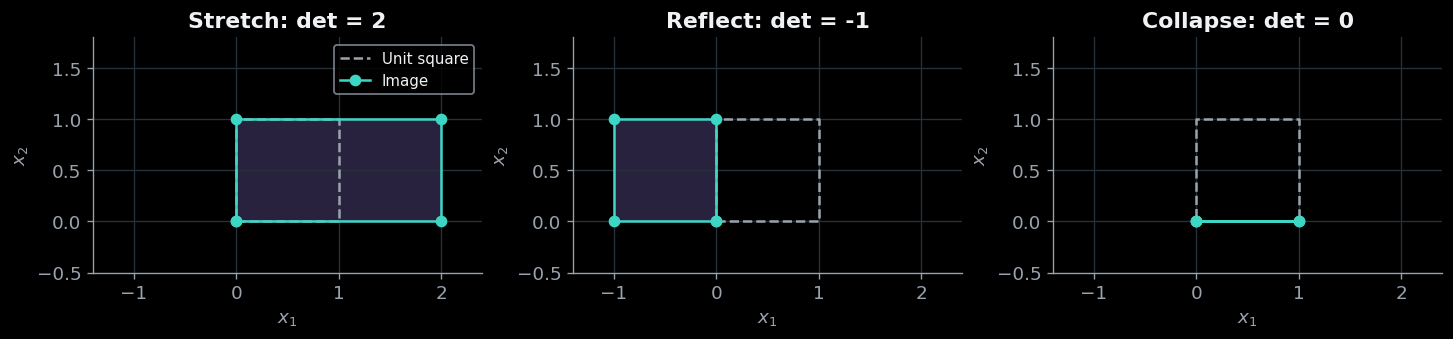

det(1e-8 I): 9.999999999999948e-25
Condition number: 1.0


In [ ]:
square = np.array([[0.,0.], [1.,0.], [1.,1.], [0.,1.], [0.,0.]])
transforms = [("Stretch", np.diag([2.,1.])),
              ("Reflect", np.diag([-1.,1.])),
              ("Collapse", np.diag([1.,0.]))]
fig, axes = plt.subplots(1, 3, figsize=(12, 4), layout="constrained")
for ax, (name, matrix) in zip(axes, transforms):
    mapped = square @ matrix.T  # Rows store points; column convention is matrix @ point.
    ax.plot(*square.T, "--", color=MUTED, label="Unit square")
    ax.fill(mapped[:,0], mapped[:,1], color=VIOLET, alpha=0.25)
    ax.plot(*mapped.T, "o-", color=CYAN, label="Image")
    ax.set(title=f"{name}: det = {np.linalg.det(matrix):.0f}",
           xlim=(-1.4, 2.4), ylim=(-0.5, 1.8), xlabel=r"$x_1$", ylabel=r"$x_2$")
    ax.set_aspect("equal")
axes[0].legend(fontsize=9)
plt.show()
small_identity = 1e-8 * np.eye(3)
print("det(1e-8 I):", np.linalg.det(small_identity))
print("Condition number:", np.linalg.cond(small_identity, np.inf))


## 6. Norms, conditioning, and residuals

Norms turn a vector or matrix into a measure of size. We will consistently use the infinity norm for error comparisons:

$$\|\mathbf{x}\|_\infty=\max_i|x_i|,\quad
\|\mathbf{x}\|_2=\sqrt{\sum_i x_i^2},\quad
\|A\|_\infty=\max_i\sum_j|a_{ij}|.$$

The induced matrix norm satisfies $\|A\mathbf{x}\|_\infty\leq\|A\|_\infty\|\mathbf{x}\|_\infty$. For invertible $A$,

$$\kappa_\infty(A)=\|A\|_\infty\|A^{-1}\|_\infty.$$

If **only $\mathbf{b}$ changes**, and $\mathbf{x}$ and $\mathbf{x}+\delta\mathbf{x}$ are the corresponding exact solutions, then

$$\frac{\|\delta\mathbf{x}\|_\infty}{\|\mathbf{x}\|_\infty}
\leq\kappa_\infty(A)
\frac{\|\delta\mathbf{b}\|_\infty}{\|\mathbf{b}\|_\infty},$$

assuming nonzero $\mathbf{b}$. This is a **worst-case upper bound**, not a prediction that every perturbation is amplified by $\kappa$.

**Predict:** two nearly parallel equations can have a very sensitive intersection. What will happen if we perturb just one right-hand-side entry below?


In [ ]:
norm_inf  = lambda x: np.max(np.abs(x))
norm_2    = lambda x: np.sqrt(np.sum(np.asarray(x,float)**2))
mat_inf   = lambda A: np.max(np.sum(np.abs(A), axis=1))     # max row sum

x = np.array([3.0, -4.0]); A = np.array([[1.0,2.0],[-3.0,1.0]])
print(f"||x||_inf = {norm_inf(x):.0f},  ||x||_2 = {norm_2(x):.0f},  ||A||_inf = {mat_inf(A):.0f}")

B = np.array([[1.0,1.0],[1.0,1.0001]])
print(f"\nkappa_inf(B) = {np.linalg.cond(B, np.inf):.3e}")
for bb in ([2.0,2.0001],[2.0,2.0002]):
    xb = np.linalg.solve(B, bb)
    print(f"  b={bb} -> x=({xb[0]:.4g},{xb[1]:.4g})")
print("An approximately 0.005% relative infinity-norm change in b moved x from (1,1) to (0,2): exactly what large kappa warns about.")


||x||_inf = 4,  ||x||_2 = 5,  ||A||_inf = 4

kappa_inf(B) = 4.000e+04
  b=[2.0, 2.0001] -> x=(1,1)
  b=[2.0, 2.0002] -> x=(0,2)
An approximately 0.005% relative infinity-norm change in b moved x from (1,1) to (0,2): exactly what large kappa warns about.


### Small residual, large solution error

For a computed solution $\widehat{\mathbf{x}}$, the **residual** is $\mathbf{r}=\mathbf{b}-A\widehat{\mathbf{x}}$. It measures how well the equations are satisfied. The **forward error** is $\widehat{\mathbf{x}}-\mathbf{x}$; measuring it requires a known reference solution.

The distinction follows from $\widehat{\mathbf{x}}-\mathbf{x}=-A^{-1}\mathbf{r}$. A sensitive system can turn a small residual into a large forward error. We also report the scaled residual

$$\eta=\frac{\|\mathbf{r}\|_\infty}
{\|A\|_\infty\|\widehat{\mathbf{x}}\|_\infty+\|\mathbf{b}\|_\infty}.$$

This is a normwise backward-error measure allowing perturbations to both $A$ and $\mathbf{b}$. It is different from forward error.


In [ ]:
def scaled_residual(A, x, b):
    residual = np.linalg.norm(b - A @ x, np.inf)
    scale = np.linalg.norm(A, np.inf)*np.linalg.norm(x, np.inf) + np.linalg.norm(b, np.inf)
    return residual/scale if scale else (0.0 if residual == 0 else np.inf)

x_true = np.array([1., 1.])
b_true = B @ x_true
x_candidate = np.array([0., 2.])
relative_residual = norm_inf(b_true-B@x_candidate) / norm_inf(b_true)
relative_error = norm_inf(x_candidate-x_true) / norm_inf(x_true)
print(f"Relative residual: {relative_residual:.3e}")
print(f"Relative forward error: {relative_error:.3e}")
print(f"Scaled residual: {scaled_residual(B, x_candidate, b_true):.3e}")
print(f"Condition-number bound: {np.linalg.cond(B, np.inf)*relative_residual:.3e}")


Relative residual: 5.000e-05
Relative forward error: 1.000e+00
Scaled residual: 1.667e-05
Condition-number bound: 2.000e+00


## 7. Practice: predict → compute → explain

Write a brief explanation as well as a numerical answer. Use the working cells as templates; the optional answer guide follows the exercise cell.

| Exercise | Task | Evidence to include |
|:--|:--|:--|
| 1 · Elimination | Solve $A=[[2,1],[4,3]]$, $\mathbf{b}=[1,3]$ with Gauss and LU. | Solution and residual; explain the first multiplier. |
| 2 · Pivoting | Use $A=[[0,1],[1,1]]$, $\mathbf{b}=[1,2]$. Explain why the unpivoted method stops. | $P,L,U$ and the solution. |
| 3 · Scaling | For $A=\alpha I_3$, compare $\alpha=10^{-8},1,10^8$. | Determinant and condition number; explain why they tell different stories. |
| 4 · Reuse | Keep `A_lu` fixed and solve for three new right-hand sides. | Verify all columns with a single matrix product. |
| 5 · Residual versus error | Use the matrix `B` from Section 6, $\mathbf{x}=(1,1)$, $\mathbf{b}=B\mathbf{x}$, and candidate $\widehat{\mathbf{x}}=(0,2)$. | Relative residual and relative forward error in the infinity norm; explain their difference. |
| 6 · Perturbation direction | Set $\mathbf{b}=B(1,1)^T$ and $\delta\mathbf{b}=10^{-3}\mathbf{b}$. Solve before and after the change. | Relative changes in the right-hand side and solution; compare their ratio with $\kappa_\infty(B)$.


In [ ]:
# Student workspace: edit these values or add your own cells.
A_exercise = np.array([[2., 1.], [4., 3.]])
b_exercise = np.array([1., 3.])
# 1. Predict the solution on paper.
# 2. Call gauss_solve or lu_pivot + lu_solve.
# 3. Evaluate b_exercise - A_exercise @ your_solution.
# 4. Explain what the residual tells you (and what it does not).


<details>
<summary><strong>Optional answer guide — open after attempting the exercises</strong></summary>

1. The first elimination multiplier is $4/2=2$. The second equation becomes $x_2=1$, so $\mathbf{x}=(0,1)$. A correct computation gives a zero or near-zero residual.
2. The first pivot is zero, but the matrix is invertible. Partial pivoting exchanges the two rows. One factorization is $P=[[0,1],[1,0]]$, $L=I$, $U=[[1,1],[0,1]]$, giving $\mathbf{x}=(1,1)$.
3. The determinants are $10^{-24},1,10^{24}$, respectively; every condition number is $1$. Uniform scaling changes volume but not relative sensitivity.
4. Factorize `A_lu` once; solve for each column of a right-hand-side matrix. Check `np.allclose(A_lu @ solutions, right_hand_sides)`.
5. The relative residual is approximately $5\times10^{-5}$, while the relative forward error is $1$. The matrix is ill-conditioned: satisfying the equations approximately does not guarantee proximity to the exact solution.
6. Both relative changes are approximately $10^{-3}$, so the observed amplification is approximately $1$, even though $\kappa_\infty(B)\approx4\times10^4$. For this particular perturbation, linearity gives $B^{-1}[(1+\alpha)\mathbf{b}]=(1+\alpha)\mathbf{x}$. The condition number provides a worst-case upper bound; not every perturbation attains it.

</details>


## 8. Numerical checks and takeaways

The final cell checks more than agreement on one example: it exercises row exchanges, reuse of factors, the determinant sign, singular input, and the distinction between residual and forward error. These checks support the examples; they do not make a small teaching implementation a general-purpose numerical library.


In [ ]:
# Reproducible checks of the key mathematical relationships.
rng = np.random.default_rng(42)
for size in [1, 2, 3, 6]:
    for _ in range(4):
        test_A = rng.normal(size=(size, size)) + np.eye(size)
        test_b = rng.normal(size=size)
        original_A, original_b = test_A.copy(), test_b.copy()
        p, lower, upper, count = lu_pivot(test_A)
        computed = lu_solve(p, lower, upper, test_b)
        np.testing.assert_allclose(p@test_A, lower@upper, atol=1e-12)
        np.testing.assert_allclose(computed, np.linalg.solve(test_A, test_b), rtol=1e-10, atol=1e-11)
        np.testing.assert_allclose(det_lu(test_A), np.linalg.det(test_A), rtol=1e-10, atol=1e-11)
        assert np.array_equal(test_A, original_A) and np.array_equal(test_b, original_b)

# This matrix requires a later exchange: previously stored L columns must move.
late_swap = np.array([[4.,1.,1.], [2.,1.,3.], [1.,5.,1.]])
p, lower, upper, count = lu_pivot(late_swap)
assert count >= 1
np.testing.assert_allclose(p@late_swap, lower@upper, atol=1e-12)

try:
    lu_pivot([[1.,2.], [2.,4.]])
except np.linalg.LinAlgError:
    pass
else:
    raise AssertionError("Singular input should be rejected.")
assert det_lu([[1.,2.], [2.,4.]]) == 0.0
np.testing.assert_allclose(det_cofactor([[2.,1.], [4.,3.]]), 2.0)

# Reuse the same factorization for several right-hand sides.
p, lower, upper, _ = lu_pivot(A_lu)
test_rhs = np.column_stack([b_lu, [1., 0., 2.], [0., 1., -1.]])
test_solutions = np.column_stack([lu_solve(p, lower, upper, rhs) for rhs in test_rhs.T])
np.testing.assert_allclose(A_lu @ test_solutions, test_rhs, atol=1e-12)

# A small residual can coexist with a large forward error.
known_solution = np.array([1., 1.])
known_rhs = B @ known_solution
candidate = np.array([0., 2.])
assert norm_inf(known_rhs - B @ candidate)/norm_inf(known_rhs) < 1e-4
np.testing.assert_allclose(norm_inf(candidate-known_solution)/norm_inf(known_solution), 1.)

# A proportional perturbation has amplification one, not kappa(B).
alpha = 1e-3
base_solution = np.linalg.solve(B, known_rhs)
changed_solution = np.linalg.solve(B, (1+alpha)*known_rhs)
np.testing.assert_allclose(changed_solution, (1+alpha)*base_solution, atol=1e-10)
print("All numerical checks passed.")


All numerical checks passed.


### Recap

- **Elimination** converts a coupled system into a triangular one; **LU** stores that work for reuse.
- **Pivoting** changes the computational path while preserving the linear system's exact solution.
- **Determinants** characterize invertibility in exact arithmetic; **condition numbers** measure relative sensitivity.
- **Residuals** measure satisfaction of the equations; **forward error** measures distance from the solution.
- A **condition-number bound** describes worst-case amplification; the direction of a particular perturbation also matters.
